# Exploratory Data Analysis (EDA)

This notebook focuses on exploring the cleaned dataset to uncover patterns, sales trends, and customer purchasing behaviors.

The objective is to extract actionable business insights, visualize key performance indicators (KPIs), and answer core business questions to support data-driven decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/processed/online_retail_cleaned.csv")

C:\Users\M.Bilal\AppData\Local\Temp\ipykernel_20032\716379580.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/online_retail_cleaned.csv")


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom,30.0


In [4]:
df.shape

(1007913, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1007913 non-null  object 
 1   StockCode    1007913 non-null  object 
 2   Description  1007913 non-null  object 
 3   Quantity     1007913 non-null  int64  
 4   InvoiceDate  1007913 non-null  object 
 5   Price        1007913 non-null  float64
 6   Customer ID  779425 non-null   float64
 7   Country      1007913 non-null  object 
 8   Revenue      1007913 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 69.2+ MB


In [6]:
df[["Quantity", "Price", "Revenue"]].describe()

,Quantity,Price,Revenue
count,1.007913e+06,1.007913e+06,1.007913e+06
mean,1.111718e+01,4.074252e+00,2.031550e+01
std,1.284700e+02,5.043045e+01,2.057158e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,2.511109e+04,1.684696e+05


In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%d/%m/%Y %H:%M")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1007913 non-null  object        
 1   StockCode    1007913 non-null  object        
 2   Description  1007913 non-null  object        
 3   Quantity     1007913 non-null  int64         
 4   InvoiceDate  1007913 non-null  datetime64[ns]
 5   Price        1007913 non-null  float64       
 6   Customer ID  779425 non-null   float64       
 7   Country      1007913 non-null  object        
 8   Revenue      1007913 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 69.2+ MB


In [9]:
total_revenue = df["Revenue"].sum()

total_orders = df["Invoice"].nunique()

total_customers = df["Customer ID"].nunique()

total_products = df["StockCode"].nunique()

In [10]:
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")

Total Revenue: £20,476,260.45
Total Orders: 40,079
Total Customers: 5,878
Total Products: 4,917


In [11]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [12]:
# Date aur Time ke naye columns extract karna
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name() # Jaise Monday, Tuesday

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 14 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1007913 non-null  object        
 1   StockCode    1007913 non-null  object        
 2   Description  1007913 non-null  object        
 3   Quantity     1007913 non-null  int64         
 4   InvoiceDate  1007913 non-null  datetime64[ns]
 5   Price        1007913 non-null  float64       
 6   Customer ID  779425 non-null   float64       
 7   Country      1007913 non-null  object        
 8   Revenue      1007913 non-null  float64       
 9   YearMonth    1007913 non-null  period[M]     
 10  Year         1007913 non-null  int32         
 11  Month        1007913 non-null  int32         
 12  Hour         1007913 non-null  int32         
 13  DayOfWeek    1007913 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(3), int64(1), object(5), p

In [14]:
df.to_csv("../data/processed/online_retail_eda.csv", index=False)

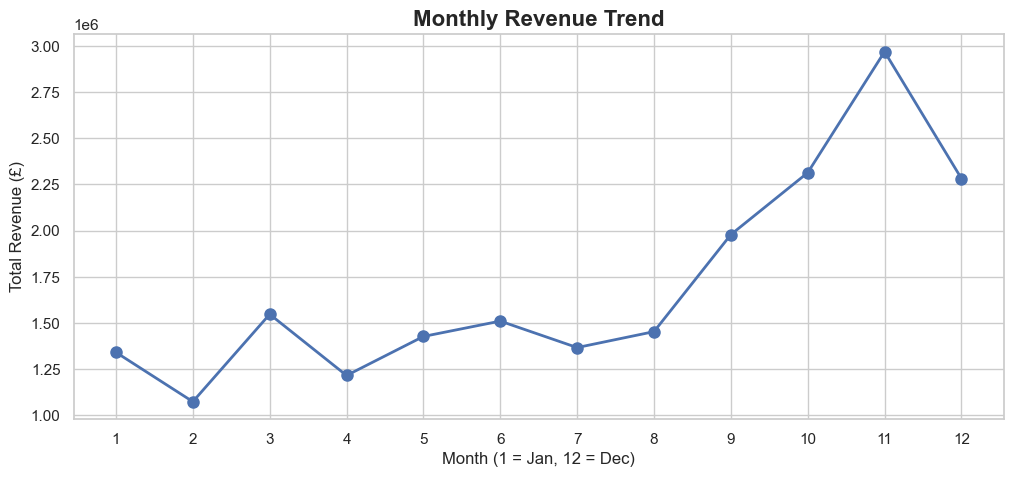

In [15]:
sns.set_theme(style="whitegrid")
monthly_sales = df.groupby('Month')['Revenue'].sum()
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='b', linewidth=2, markersize=8)
plt.title("Monthly Revenue Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month (1 = Jan, 12 = Dec)", fontsize=12)
plt.ylabel("Total Revenue (£)", fontsize=12)
plt.xticks(range(1, 13)) 
plt.show()

### Insight

Revenue shows seasonal fluctuations throughout the year.
Further investigation is required to identify peak sales periods.

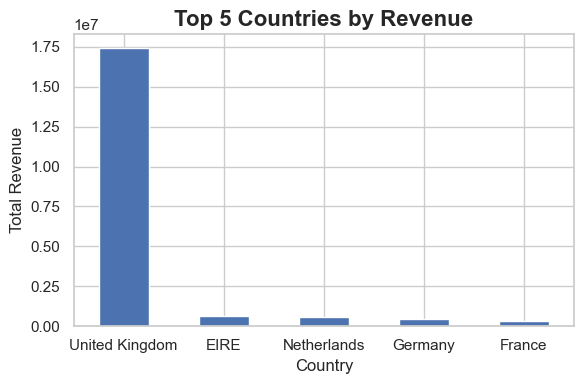

In [16]:
top_countries= (
    df.groupby("Country")["Revenue"].sum()
    .sort_values(ascending = False)
    .head(5)
)
plt.figure(figsize= (6, 4))
top_countries.plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Top 5 Countries by Revenue",fontsize=16, fontweight="bold")
plt.xticks(rotation=False)
plt.tight_layout()
plt.show()

### Insight

* The United Kingdom generates the highest revenue among all countries.
* Revenue contribution from the UK is significantly larger than other markets.
* International markets contribute a smaller share of total sales.
* The business appears highly dependent on the UK customer base.


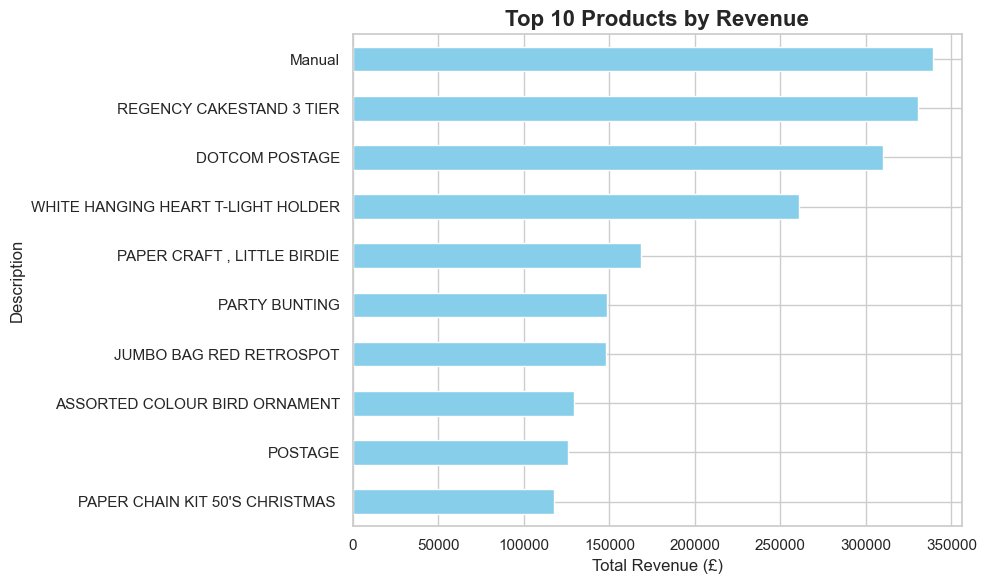

In [17]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 6))
top_products.plot(kind="barh", color="skyblue")
plt.xlabel("Total Revenue (£)")
plt.title("Top 10 Products by Revenue", fontsize=16, fontweight="bold")
plt.gca().invert_yaxis() # Highest revenue product ko top par dikhane ke liye
plt.tight_layout()
plt.show()

### Insight

* A small number of products generate a large share of total revenue.
* Best-selling products contribute significantly to overall business performance.
* These products should be prioritized for inventory planning and marketing efforts.
* Revenue concentration suggests opportunities for product-focused promotions.


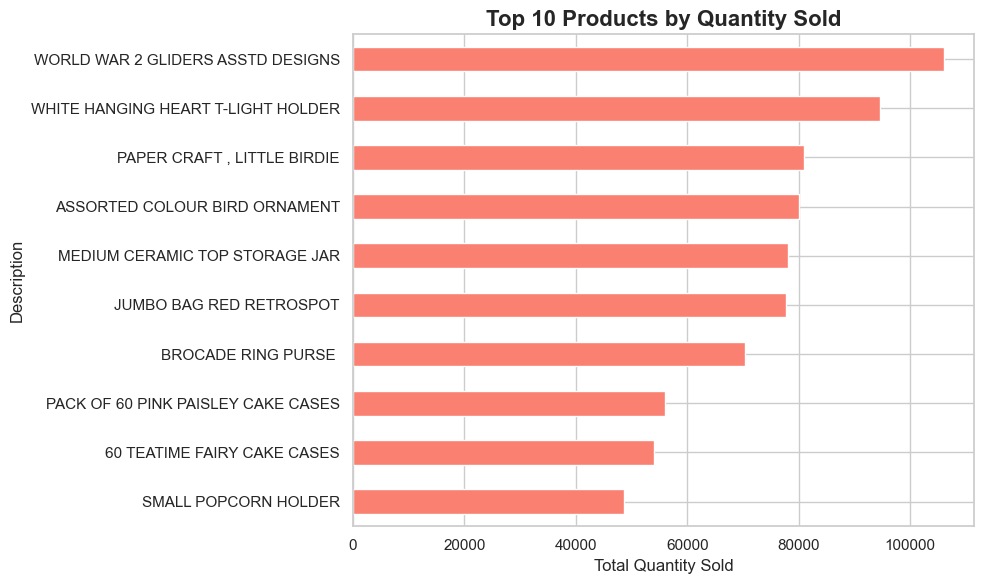

In [18]:
top_quantity_products = (
    df. groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 6))
top_quantity_products.plot(kind="barh", color="salmon")
plt.xlabel("Total Quantity Sold")
plt.title("Top 10 Products by Quantity Sold", fontsize=16, fontweight="bold")
plt.gca().invert_yaxis() # Highest quantity product ko top par dikhane ke liye
plt.tight_layout()
plt.show()

### Insight

* High-volume products are purchased frequently by customers.
* Popular products may not always generate the highest revenue.
* Inventory management should ensure consistent availability of these items.
* Understanding demand patterns can help reduce stock shortages.


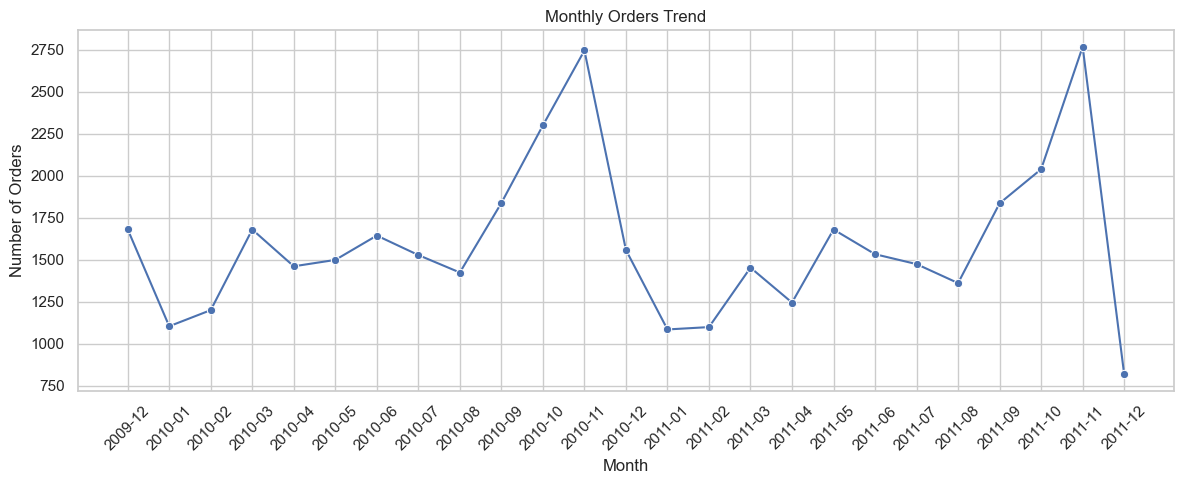

In [19]:
monthly_orders = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))['Invoice']
      .nunique()
      .reset_index()
)

monthly_orders['InvoiceDate'] = monthly_orders['InvoiceDate'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_orders,
             x='InvoiceDate',
             y='Invoice',
             marker='o')

plt.xticks(rotation=45)
plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### Insight

- Orders show a clear upward trend over time.
- Seasonal peaks can be observed during holiday periods.
- Higher order volume generally corresponds with higher revenue months.

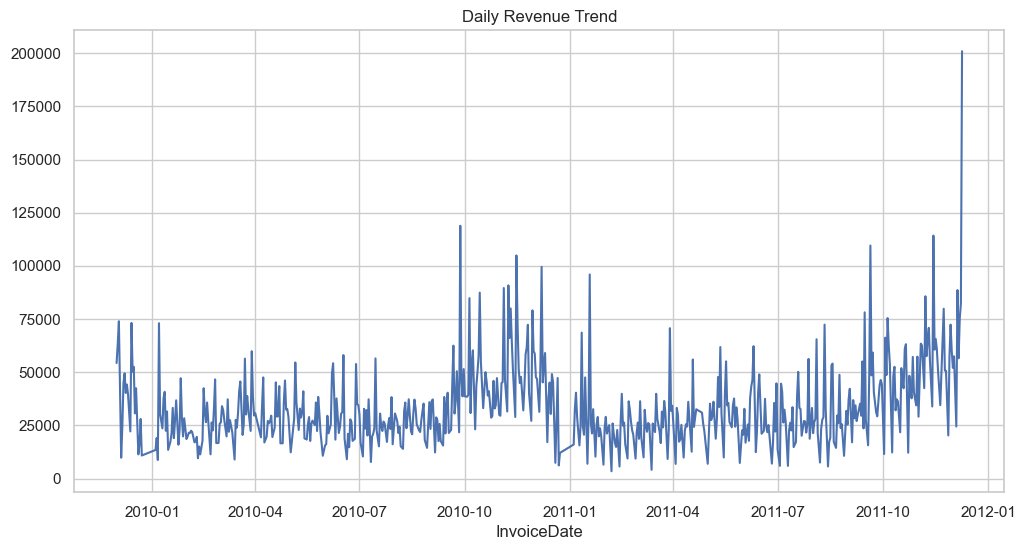

In [20]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue"]
      .sum()
)

plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title("Daily Revenue Trend")
plt.show()

### Insight

- Daily sales fluctuate significantly over time.
- Certain days show unusually high revenue, indicating bulk purchases or seasonal demand.
- Overall sales activity increased over the observed period.

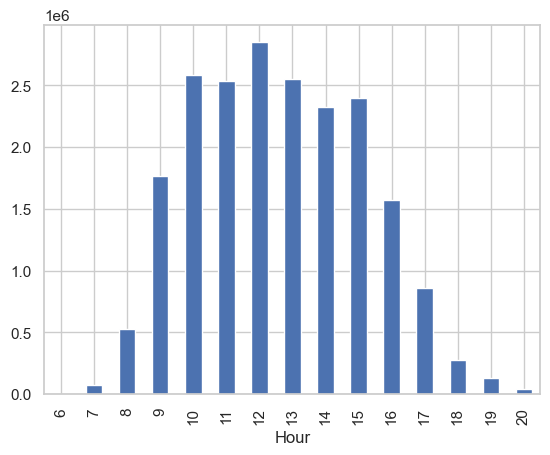

In [21]:
hourly_sales = df.groupby("Hour")["Revenue"].sum()

hourly_sales.plot(kind="bar")
plt.show()

### Insight

- Most sales occur during business hours.
- Customer purchasing activity peaks during the middle of the day.
- Very few transactions occur during late-night hours.

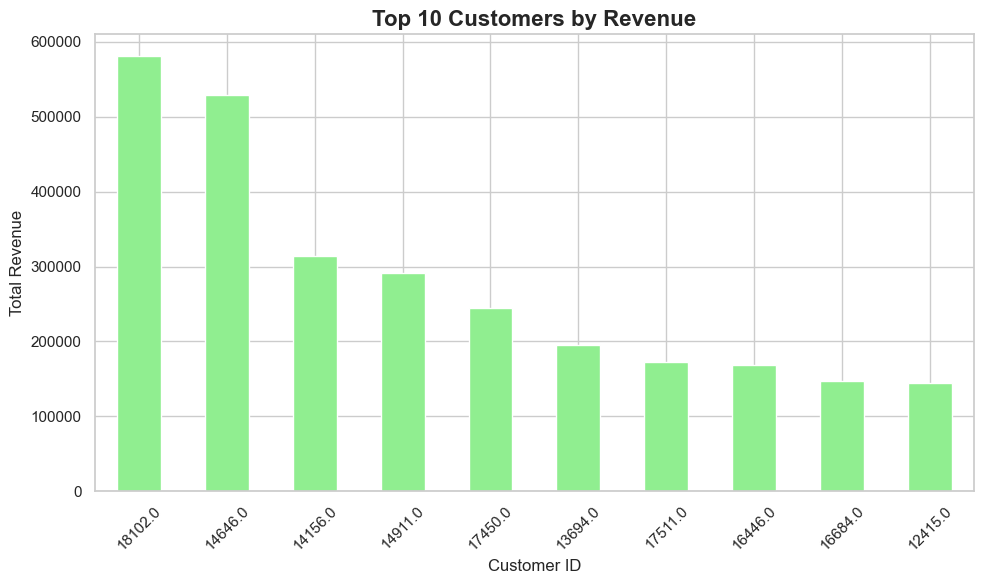

In [22]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 6))
top_customers.plot(kind="bar", color="lightgreen")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.title("Top 10 Customers by Revenue", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

- A small group of customers contributes a large share of total revenue.
- These customers can be considered high-value customers.
- Retention strategies for these customers could significantly impact business performance.

03_eda.ipynb

1. Dataset Overview
2. Business KPIs
3. Monthly Revenue Trend
4. Monthly Orders Trend
5. Top Countries
6. Top Products by Revenue
7. Top Products by Quantity
8. Revenue Distribution
9. Daily Revenue Trend
10. Top Customers
11. Key Business Insights

# EDA Summary

Key Findings:

- UK generated the majority of revenue.
- Sales peak during holiday seasons.
- A small number of products generate a large share of revenue.
- Customer spending is highly concentrated among top customers.
- Revenue shows strong seasonality.
